In [ ]:
Setup & Install Library

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from transformers import pipeline
import re
import warnings
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette("Set2")

print("✅ Setup & Libraries Complete!")

✅ Setup & Libraries Complete!


In [2]:
dataset_url = "https://api.apify.com/v2/datasets/bYlNHwltJkahTVWGf/items?signature=MC4wLnR3OTVCazVHT2pOdFZEODVMNE1B"

print("⏳ Menarik data komentar TikTok secara langsung dari Dataset URL...")

try:
    response = requests.get(dataset_url)
    response.raise_for_status()
    data = response.json()

    real_comments = []

    for item in data:
        text = item.get("text", "")
        username = item.get("uniqueId", "unknown")
        likes = item.get("diggCount", 0)
        date = item.get("createTimeISO", "")

        if str(text).strip() != "":
            real_comments.append({
                "platform": "tiktok",
                "post_id": "7288962732391451909",
                "date": date,
                "username": username,
                "comment_text": text,
                "likes_count": likes
            })

    df_comments = pd.DataFrame(real_comments)

    if len(df_comments) > 500:
        df_comments = df_comments.head(500)

    print(f"✅ Sukses! Berhasil memuat {len(df_comments)} komentar asli.")
    display(df_comments.head(10))

except Exception as e:
    print(f" Terjadi kesalahan saat menarik data. Pastikan URL sudah benar. Detail Error: {e}")

⏳ Menarik data komentar TikTok secara langsung dari Dataset URL...
✅ Sukses! Berhasil memuat 500 komentar asli.


,platform,post_id,date,username,comment_text,likes_count
0,tiktok,7288962732391451909,2023-10-12T09:44:11.000Z,caramelmacciyunho,Lah baru sadar ini dr tirta,275
1,tiktok,7288962732391451909,2023-10-12T09:46:29.000Z,kai121_,"Wah, terima kasih atas apresiasi dan kritiknya...",2771
2,tiktok,7288962732391451909,2023-10-12T07:24:00.000Z,quotestentangrindu,senin minggu lalu ketemu dr tirta di argo lawu...,0
3,tiktok,7288962732391451909,2023-10-12T09:12:53.000Z,handithung,"1,6 ojo turu dok, emann😭",2978
4,tiktok,7288962732391451909,2023-10-12T15:01:32.000Z,rimbakanui,"Jakarta-jogja 1,6 waktu tempuh sekitar 7 jam, ...",251
5,tiktok,7288962732391451909,2024-04-11T02:28:45.000Z,c_coco14,"kesini gara"" kakek 71 tahun",224
6,tiktok,7288962732391451909,2023-10-12T07:52:12.000Z,feniewati,enak naik pesawat lah🤣kalau jkt jogja,52
7,tiktok,7288962732391451909,2023-10-12T08:01:13.000Z,toystalgic,Cuma ada yang tujuan jogja ya??,10
8,tiktok,7288962732391451909,2023-11-24T23:17:08.000Z,ard_103,Tiket nya Bli dimana sih kalo naik kereta yang...,7
9,tiktok,7288962732391451909,2023-10-17T07:16:45.000Z,arnandofirhan,Dok Argo Semeru barusan keluar dr gerbongnya d...,75


In [3]:
print("⏳ Memuat model AI IndoBERT (mungkin memakan waktu belasan detik)...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="w11wo/indonesian-roberta-base-sentiment-classifier",
    device=0
)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()

df_comments['comment_text'] = df_comments['comment_text'].str.replace('#', '', regex=False)
df_comments['cleaned_text'] = df_comments['comment_text'].apply(clean_text)

def get_indobert_sentiment(text):
    try:
        if not text: return 'neutral', 0.0
        result = sentiment_pipeline(text, truncation=True, max_length=512)[0]
        return result['label'].lower(), result['score']
    except Exception:
        return 'neutral', 0.0

print(f"🧠 AI Sedang Membaca & Memproses Sentimen pada {len(df_comments)} Komentar Asli...")

sentiments_and_scores = df_comments['cleaned_text'].apply(get_indobert_sentiment)

df_comments['sentiment'] = [res[0] for res in sentiments_and_scores]
df_comments['confidence'] = [res[1] for res in sentiments_and_scores]

print("✅ Analisis Sentimen Selesai!")
display(df_comments[['username', 'comment_text', 'sentiment', 'likes_count']].head(15))

⏳ Memuat model AI IndoBERT (mungkin memakan waktu belasan detik)...


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

🧠 AI Sedang Membaca & Memproses Sentimen pada 500 Komentar Asli...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Analisis Sentimen Selesai!


,username,comment_text,sentiment,likes_count
0,caramelmacciyunho,Lah baru sadar ini dr tirta,negative,275
1,kai121_,"Wah, terima kasih atas apresiasi dan kritiknya...",positive,2771
2,quotestentangrindu,senin minggu lalu ketemu dr tirta di argo lawu...,neutral,0
3,handithung,"1,6 ojo turu dok, emann😭",negative,2978
4,rimbakanui,"Jakarta-jogja 1,6 waktu tempuh sekitar 7 jam, ...",positive,251
5,c_coco14,"kesini gara"" kakek 71 tahun",negative,224
6,feniewati,enak naik pesawat lah🤣kalau jkt jogja,positive,52
7,toystalgic,Cuma ada yang tujuan jogja ya??,negative,10
8,ard_103,Tiket nya Bli dimana sih kalo naik kereta yang...,negative,7
9,arnandofirhan,Dok Argo Semeru barusan keluar dr gerbongnya d...,neutral,75


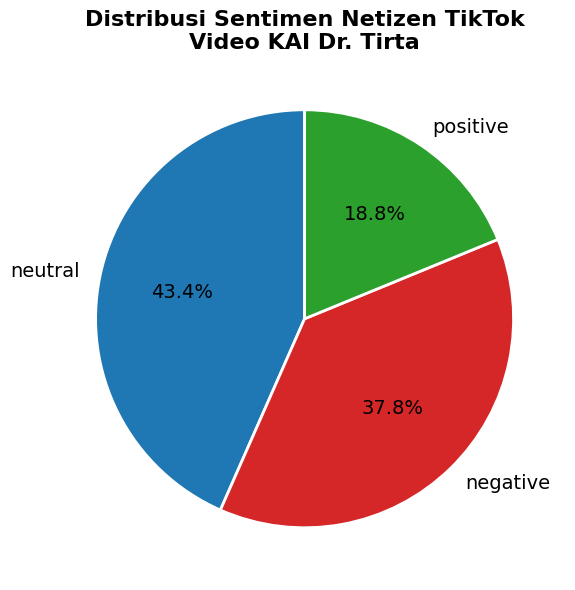

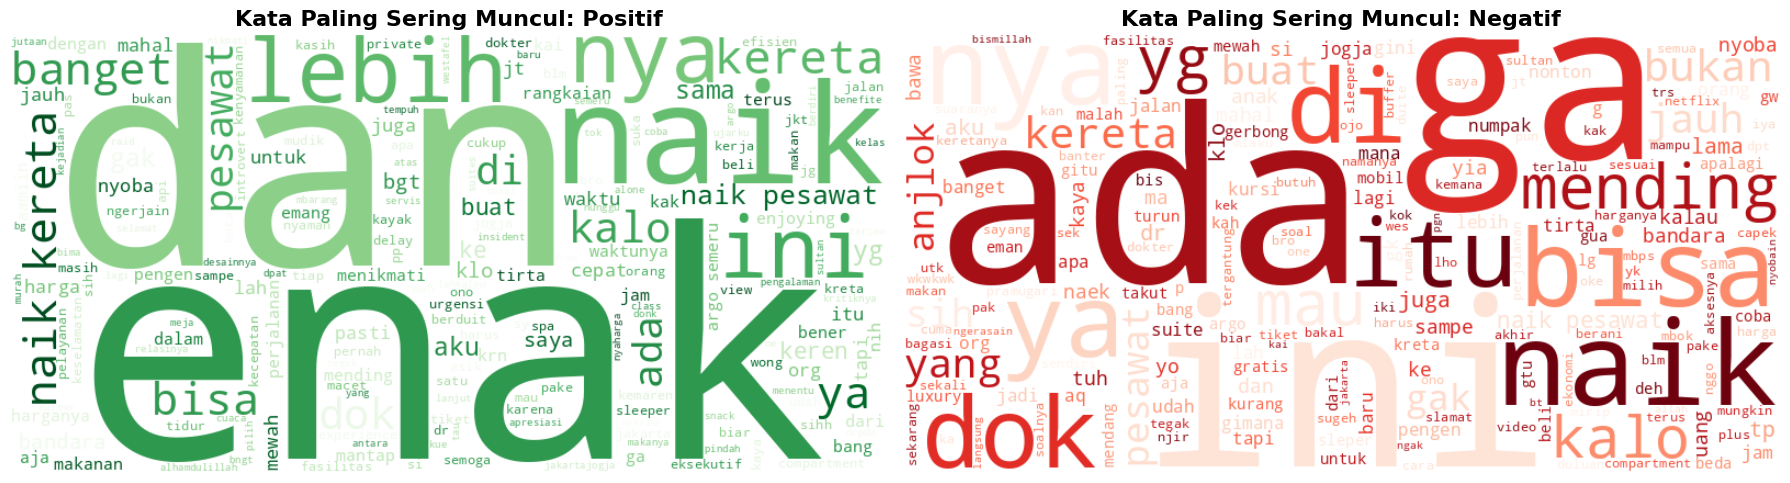

In [4]:
sentiment_counts = df_comments['sentiment'].value_counts()
color_map = {'positive': '#2ca02c', 'negative': '#d62728', 'neutral': '#1f77b4'}

plt.figure(figsize=(8, 6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=[color_map.get(x, '#333333') for x in sentiment_counts.index],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 14})
plt.title(f"Distribusi Sentimen Netizen TikTok\nVideo KAI Dr. Tirta", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

pos_text = " ".join(df_comments[df_comments['sentiment'] == 'positive']['cleaned_text'])
neg_text = " ".join(df_comments[df_comments['sentiment'] == 'negative']['cleaned_text'])

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

if pos_text.strip() != "":
    wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
    ax[0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0].set_title('Kata Paling Sering Muncul: Positif', fontsize=16, fontweight='bold')
ax[0].axis('off')

if neg_text.strip() != "":
    wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)
    ax[1].imshow(wordcloud_neg, interpolation='bilinear')
ax[1].set_title('Kata Paling Sering Muncul: Negatif', fontsize=16, fontweight='bold')
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
output_filename = 'Hasil_Analisis_TikTok_DrTirta_KAI.csv'
df_comments.to_csv(output_filename, index=False)

print(f"✅ Data komprehensif berhasil disimpan ke '{output_filename}'")
print("\n📊 Rincian Angka Sentimen:")
print(sentiment_counts)

✅ Data komprehensif berhasil disimpan ke 'Hasil_Analisis_TikTok_DrTirta_KAI.csv'

📊 Rincian Angka Sentimen:
sentiment
neutral     217
negative    189
positive     94
Name: count, dtype: int64
